In [1]:
# importing the cv2 library
import cv2

# loading the haar case algorithm file into variable
algorithm = "haarcascade_frontalface_default.xml"

In [2]:
# passing the algorithm to OpenCV
haar_cascade = cv2.CascadeClassifier(algorithm)

In [3]:
# loading the image path into file_name variable - I have Generated my own image using chatGPT it i snot a real one it is only for practice
file_name = "generatedImage.png"

In [4]:
# reading the image
img = cv2.imread(file_name, 0)

In [5]:
from matplotlib import pyplot as plt

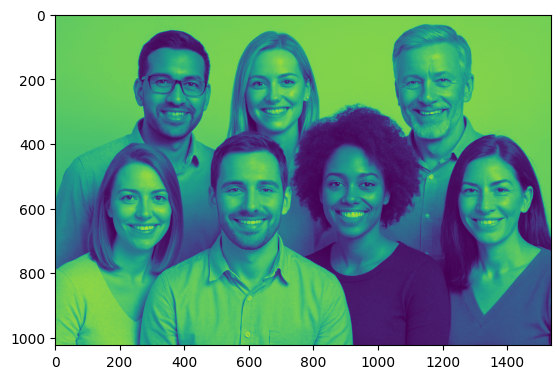

In [6]:
plt.imshow(img)
plt.show()

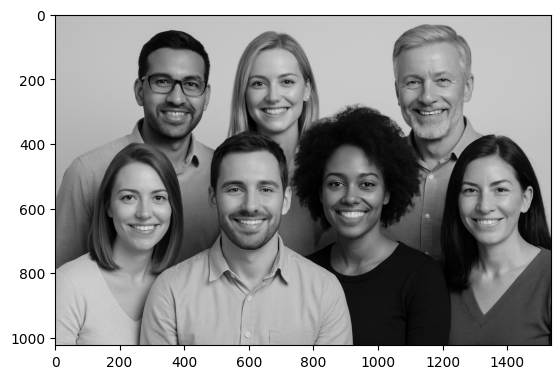

In [7]:
# creating a black and white version of the image
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
plt.imshow(gray_img)
plt.show()

In [8]:
# detecting the faces
faces = haar_cascade.detectMultiScale(
    gray_img, scaleFactor=1.05, minNeighbors=5, minSize=(100, 100)
)

In [9]:
i = 0
# for each face detected
for x, y, w, h in faces:
    # crop the image to select only the face
    cropped_image = img[y : y + h, x : x + w]
    # saving each face in a folder
    target_file_name = 'stored-faces/' + str(i) + '.jpg'
    cv2.imwrite(
        target_file_name,
        cropped_image,
    )
    i = i + 1;

# Embeddings Calculation
### Calculate embeddings from the faces and saving them in MongoDB

In [ ]:
from pymongo import MongoClient
from PIL import Image
import numpy as np
import torch
from transformers import CLIPProcessor, CLIPModel
import os

In [ ]:
# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client.face_db
collection = db.pictures

# Load CLIP (image encoder)
model_id = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

# Function: compute embedding
def compute_embedding(img_path):
    image = Image.open(img_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        embedding = model.get_image_features(**inputs)

    embedding = embedding.squeeze().numpy().tolist()
    return embedding


#Loop through stored images
folder = "stored-faces"

for filename in os.listdir(folder):
    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    file_path = os.path.join(folder, filename)

    print("Processing:", filename)

    emb = compute_embedding(file_path)

    # save to MongoDB (upsert)
    collection.update_one(
        {"filename": filename},
        {"$set": {
            "filename": filename,
            "embedding": emb
        }},
        upsert=True
    )

    print("Saved:", filename)

print("Done!")

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingfac

Processing: 0.jpg
Saved: 0.jpg
Processing: 1.jpg
Saved: 1.jpg
Processing: 2.jpg
Saved: 2.jpg
Processing: 3.jpg
Saved: 3.jpg
Processing: 4.jpg
Saved: 4.jpg
Processing: 5.jpg
Saved: 5.jpg
Processing: 6.jpg
Saved: 6.jpg
Done!


# Calculate embedding for a new picture

In [12]:
# load CLIP model
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

# step equivalent
file_name = "generatedImage2.png"  # your test image
image = Image.open(file_name).convert("RGB")

inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    embedding = model.get_image_features(**inputs)

embedding = embedding.squeeze().numpy().tolist()

print("Embedding vector length:", len(embedding))
print("Embedding example values:", embedding[:10])


Embedding vector length: 512
Embedding example values: [0.5717830657958984, 0.09088899195194244, -0.25460949540138245, 0.13189785182476044, 0.21198183298110962, -0.21125704050064087, 0.20250248908996582, 0.7715295553207397, 0.5205339193344116, 0.163345605134964]


In [15]:
#Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client.face_db
collection = db.pictures

In [16]:
#Load CLIP (same encoder)
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

In [17]:
#Compute embedding for query image
def compute_embedding(img_path):
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        emb = model.get_image_features(**inputs)
    return emb.squeeze().numpy()

In [18]:
# Cosine similarity
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [23]:
#Query image
query_image = "generatedImage4.png"
query_emb = compute_embedding(query_image)

In [24]:
#Fetch all stored embeddings from MongoDB
docs = list(collection.find({}))

In [25]:
#Compute similarity for each image
best_match = None
best_score = -1

for doc in docs:
    score = cosine_similarity(query_emb, doc["embedding"])
    if score > best_score:
        best_score = score
        best_match = doc

Most similar file: 0.jpg
Similarity score: 0.8837133513739547


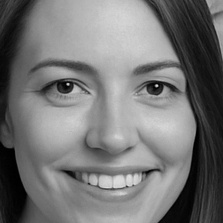

In [26]:
#Show result
print("Most similar file:", best_match["filename"])
print("Similarity score:", best_score)

from IPython.display import Image as JImage, display
display(JImage(filename="stored-faces/" + best_match["filename"]))